# Práctica 5: Modelos Lineales y Correlación

Para esta quinta práctica, se ejecuta código para realizar modelo de regresión lineal y observar la correlación de las variables.

## Librerías

Se importan las librerías necesarias.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## Importación de los datos desde CSV

Se crea una copia del dataset limpio para manejarlo.

In [15]:
# Se carga el conjunto de datos limpio.
df_original = pd.read_csv("C:\\Users\\Paty-\\OneDrive\\Documentos\\04 Facultad\\Séptimo Semestre\\Minería de Datos\\CardiovascularDiseaseDataMining\\Practica1\\cardiovascular_disease_cleaned.csv", sep=";")

# Se crea una copia del conjunto de datos limpio para trabajar en ella.
df = df_original.copy()

# Se muestran las primeras filas del conjunto de datos.
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,birth_date,age_scaled,height_scaled,weight_scaled,ap_hi_scaled,ap_lo_scaled
0,0,50,Male,168,62.0,110,80,Normal,Normal,No,No,Yes,No,1968-10-15 09:32:17.835072,-0.426244,0.477190,-0.911143,-1.149090,-0.221435
1,1,55,Female,156,85.0,140,90,Well Above Normal,Normal,No,No,Yes,Yes,1963-10-07 09:32:17.835072,0.315922,-1.116157,0.963057,0.950300,1.081779
2,2,51,Female,165,64.0,130,70,Well Above Normal,Normal,No,No,No,Yes,1967-07-09 09:32:17.835072,-0.277811,0.078853,-0.748169,0.250504,-1.524649
3,3,48,Male,169,82.0,150,100,Normal,Normal,No,No,Yes,Yes,1970-11-24 09:32:17.835072,-0.723111,0.609969,0.718596,1.650097,2.384993
4,8,59,Female,151,67.0,120,80,Above Normal,Above Normal,No,No,No,No,1959-02-24 09:32:17.835072,0.909656,-1.780052,-0.503708,-0.449293,-0.221435


## Correlación entre variables

Se analiza la correlación entre las variables numéricas.

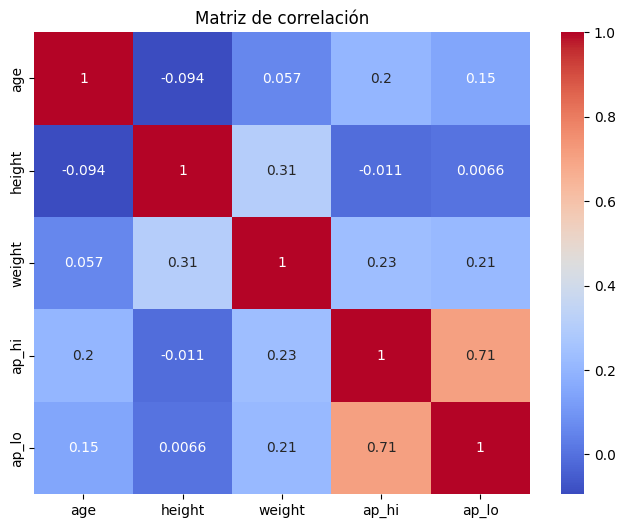

In [16]:
# variables numéricas.
numerical_vars = ['age','height','weight','ap_hi','ap_lo']

corr = df[numerical_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## Codificamos variables categóricas para utilizarlas

In [37]:
df = pd.get_dummies(df_original, columns=[
    'cholesterol','gluc','smoke','alco','active','gender'
], drop_first=True)

df['cardio'] = df['cardio'].map({'Yes': 1, 'No': 0})

## Seleccionamos variables a utilizar

In [47]:
X = df[
    [
        'age',
        'height',
        'weight',
        'ap_lo',
        'cardio',
        'cholesterol_Normal',
        'cholesterol_Well Above Normal',
        'gluc_Normal',
        'gluc_Well Above Normal',
        'smoke_Yes',
        'alco_Yes',
        'active_Yes',
        'gender_Male'
    ]
]

y = df['ap_hi']

## Modelo de regresión lineal

Se busca predecir la variable ap_hi (presión sistólica), en base a la edad, altura y peso de un paciente.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Valor de R2

In [49]:
r2 = r2_score(y_test, y_pred)

print("R2 score:", r2)

R2 score: 0.5494537672019735
